### Escuela Politécnica Nacional ###

**Nombre:** Kevin Eduardo Garcia Rodriguez

**Tema:** [Taller 5] Minimos Cuadrados

**Repositorio GIT:** https://github.com/Nattyrd/Metodos-Numericos-2025B

### EJERCICIO 1 (VERIFICACION)

In [8]:
import logging
from sys import stdout
from datetime import datetime
import os
import numpy as np
from typing import Callable
import matplotlib.pyplot as plt

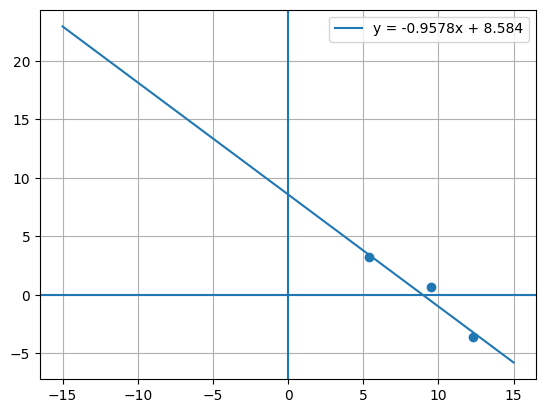

In [2]:
# Parámetros de la recta
m = -0.9578
b = 8.584

# Valores de x para la recta
x = np.linspace(-15, 15, 100)
y = m*x + b

# Puntos personalizados
puntos_x = [5.4, 9.5, 12.3]
puntos_y = [3.2, 0.7, -3.6]

# Gráfica
plt.plot(x, y, label=f"y = {m}x + {b}")
plt.scatter(puntos_x, puntos_y)

# Detalles
plt.axhline(0)
plt.axvline(0)
plt.grid()
plt.legend()
plt.show()

### EJERCICIO 1 con el codigo de git

In [7]:
# Derivadas parciales para regresión lineal
# ####################################################################
def der_parcial_1(xs: list, ys: list) -> tuple[float, float, float]:
    """Retorna los coeficientes de la ecuación de la derivada parcial con respecto al parámetro 1 al reemplazar los valores ``xs`` y ``ys``. La ecuación es de la forma:
    c_1 * a_1 + c_0 * a_0 = c_ind


    ## Parameters

    ``xs``: lista de valores de x.

    ``ys``: lista de valores de y.

    ## Return

    ``c_1``: coeficiente del parámetro 1.

    ``c_0``: coeficiente del parámetro 0.

    ``c_ind``: coeficiente del término independiente.

    """

    # coeficiente del término independiente
    c_ind = sum(ys)

    # coeficiente del parámetro 1
    c_1 = sum(xs)

    # coeficiente del parámetro 0
    c_0 = len(xs)

    return (c_1, c_0, c_ind)


def der_parcial_0(xs: list, ys: list) -> tuple[float, float, float]:
    """Retorna los coeficientes de la ecuación de la derivada parcial con respecto al parámetro 0 al reemplazar los valores ``xs`` y ``ys``. La ecuación es de la forma:
    c_1 * a_1 + c_0 * a_0 = c_ind


    ## Parameters

    ``xs``: lista de valores de x.

    ``ys``: lista de valores de y.

    ## Return

    ``c_1``: coeficiente del parámetro 1.

    ``c_0``: coeficiente del parámetro 0.

    ``c_ind``: coeficiente del término independiente.

    """
    c_1 = 0
    c_0 = 0
    c_ind = 0
    for xi, yi in zip(xs, ys):
        # coeficiente del término independiente
        c_ind += xi * yi

        # coeficiente del parámetro 1
        c_1 += xi * xi

        # coeficiente del parámetro 0
        c_0 += xi

    return (c_1, c_0, c_ind)



xs = [
     3.38,  0.35,  2.07, -0.45, -0.56,
    -1.06, -2.78,  3.08, -3.99, -5.00,
    -3.18, -1.97,  2.37, -1.67,  4.09,
    -4.60,  2.68,  2.78, -3.79, -1.87
]

ys = [
     15.65, -11.20,  -4.00,  18.03,   7.94,
     15.32,  -4.40,   1.39, -11.92, -90.24,
      6.92,  28.35,  -2.41,  -5.47,  35.91,
    -55.53,   0.77,   4.79, -27.05,   2.85
]





In [5]:

logging.basicConfig(
    level=logging.INFO,
    format="[%(asctime)s][%(levelname)s] %(message)s",
    stream=stdout,
    datefmt="%m-%d %H:%M:%S",
)
logging.info(f"{os.getlogin()}| {datetime.now()}")


# ####################################################################
def ajustar_min_cuadrados(
    xs: list,
    ys: list,
    gradiente: list[Callable[[list[float], list[float]], tuple]],
) -> np.ndarray:
    """Resuelve el sistema de ecuaciones para encontrar los parámetros del método de mínimos cuadrados. Plantea el sistema de ecuaciones lineales al reemplazar los valores de ``xs`` y ``ys`` en las derivadas parciales.

    ## Parameters

    ``xs``: lista con los valores de x.

    ``ys``: lista con los valores de y.

    ``gradiente``: lista con las funciones de derivadas parciales de ``fcn``.
    [IMPORTANTE] Cada función debe ser de la forma ``der_parcial(xi, yi)->``.

    ## Return

    ``solucion``: vector con la solución del sistema de ecuaciones lineales.

    """

    assert len(xs) == len(ys), "xs y ys deben tener la misma longitud."

    n = len(xs)

    num_pars = len(gradiente)
    logging.info(f"Se ajustarán {num_pars} parámetros.")
    # --- construir matriz A y vector b
    Ab = np.zeros((num_pars, num_pars + 1), dtype=float)

    for i, der_parcial in enumerate(gradiente):
        assert callable(der_parcial), "Cada derivada parcial debe ser una función."

        Ab[i, :] = der_parcial(xs, ys)

    # Solve the linear system using NumPy
    A = Ab[:, :-1]
    b = Ab[:, -1]
    return np.linalg.solve(A, b)


[12-15 20:58:33][INFO] NattyrdGT| 2025-12-15 20:58:33.281249


In [ ]:
a0,a1=ajustar_min_cuadrados(xs, ys, [der_parcial_1, der_parcial_0])

[12-15 21:01:28][INFO] Se ajustarán 2 parámetros.


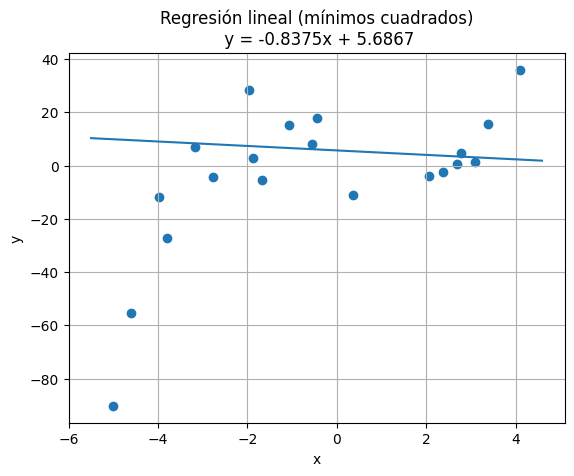

In [10]:
# ===============================
# Gráfica
# ===============================

# Convertir a numpy (por comodidad)
xs_np = np.array(xs)
ys_np = np.array(ys)

# Recta "infinita" en la cuadrícula
x_recta = np.linspace(
    xs_np.min() - 0.5,
    xs_np.max() + 0.5,
    500
)
y_recta = a1 * x_recta + a0

plt.figure()
plt.scatter(xs_np, ys_np)          # puntos
plt.plot(x_recta, y_recta)         # recta
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Regresión lineal (mínimos cuadrados)\n y = {a1:.4f}x + {a0:.4f}")
plt.grid(True)
# UTILICE:

plt.show()

### EJERCICIO 2 (Ajustado para polinomios de diferentes grados)

[12-15 21:10:46][INFO] NattyrdGT | 2025-12-15 21:10:46.433883
[12-15 21:10:46][INFO] Se ajustarán 4 parámetros.

Coeficientes encontrados:
a_0 = 2.762289919876817
a_1 = -8.880663970075585
a_2 = 0.03132740575355748
a_3 = 1.0449779168247044


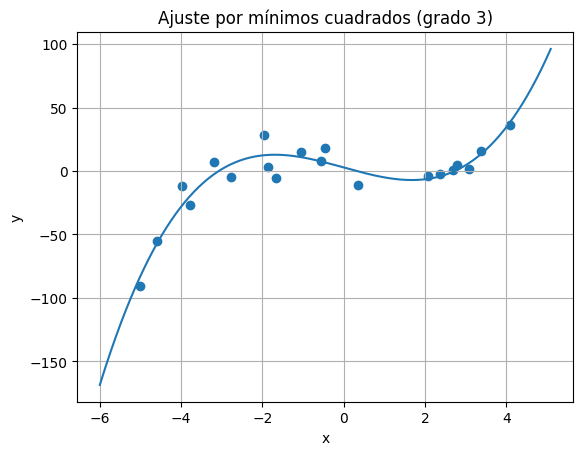

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import logging
import os
from datetime import datetime
from sys import stdout
from typing import Callable

# =========================================================
# LOGGING
# =========================================================
logging.basicConfig(
    level=logging.INFO,
    format="[%(asctime)s][%(levelname)s] %(message)s",
    stream=stdout,
    datefmt="%m-%d %H:%M:%S",
)
logging.info(f"{os.getlogin()} | {datetime.now()}")

# =========================================================
# DERIVADAS PARCIALES GENERALIZADAS
# =========================================================
def der_parcial_polinomio(j: int, grado: int):
    """
    Derivada parcial respecto a a_j para un polinomio de grado dado.
    """

    def der(xs: list[float], ys: list[float]) -> tuple:
        coeffs = []
        for k in range(grado + 1):
            coeffs.append(sum(x ** (j + k) for x in xs))

        c_ind = sum(y * (x ** j) for x, y in zip(xs, ys))
        return (*coeffs, c_ind)

    return der

# =========================================================
# MÍNIMOS CUADRADOS
# =========================================================
def ajustar_min_cuadrados(
    xs: list[float],
    ys: list[float],
    gradiente: list[Callable[[list[float], list[float]], tuple]],
) -> np.ndarray:

    assert len(xs) == len(ys), "xs y ys deben tener la misma longitud."

    num_pars = len(gradiente)
    logging.info(f"Se ajustarán {num_pars} parámetros.")

    Ab = np.zeros((num_pars, num_pars + 1), dtype=float)

    for i, der_parcial in enumerate(gradiente):
        Ab[i, :] = der_parcial(xs, ys)

    A = Ab[:, :-1]
    b = Ab[:, -1]

    return np.linalg.solve(A, b)

# =========================================================
# FUNCIÓN DE EVALUACIÓN DEL POLINOMIO
# =========================================================
def evaluar_polinomio(x: np.ndarray, coeficientes: np.ndarray) -> np.ndarray:
    """
    Evalúa el polinomio:
        y = a0 + a1*x + a2*x^2 + ...
    """
    y = np.zeros_like(x, dtype=float)
    for i, a in enumerate(coeficientes):
        y += a * (x ** i)
    return y

# =========================================================
# DATOS
# =========================================================
xs = [
     3.38,  0.35,  2.07, -0.45, -0.56,
    -1.06, -2.78,  3.08, -3.99, -5.00,
    -3.18, -1.97,  2.37, -1.67,  4.09,
    -4.60,  2.68,  2.78, -3.79, -1.87
]

ys = [
     15.65, -11.20,  -4.00,  18.03,   7.94,
     15.32,  -4.40,   1.39, -11.92, -90.24,
      6.92,  28.35,  -2.41,  -5.47,  35.91,
    -55.53,   0.77,   4.79, -27.05,   2.85
]

# =========================================================
# CONFIGURACIÓN DEL MODELO
# =========================================================
GRADO = 3   # ← cambia aquí: 1, 2, 3, ...

gradiente = [
    der_parcial_polinomio(j, GRADO)
    for j in range(GRADO + 1)
]

# =========================================================
# AJUSTE
# =========================================================
coeficientes = ajustar_min_cuadrados(xs, ys, gradiente)

# =========================================================
# RESULTADO EN CONSOLA
# =========================================================
print("\nCoeficientes encontrados:")
for i, a in enumerate(coeficientes):
    print(f"a_{i} = {a}")

# =========================================================
# GRÁFICA
# =========================================================
xs_np = np.array(xs)
ys_np = np.array(ys)

# Rango amplio para curva "continua"
x_plot = np.linspace(xs_np.min() - 1, xs_np.max() + 1, 500)
y_plot = evaluar_polinomio(x_plot, coeficientes)

plt.figure()
plt.scatter(xs_np, ys_np)          # puntos originales
plt.plot(x_plot, y_plot)           # curva ajustada
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Ajuste por mínimos cuadrados (grado {GRADO})")
plt.grid(True)
plt.show()
